In [1]:
import pandas, matplotlib_venn, matplotlib

In [2]:
a = pandas.read_csv('deseq2.tsv', sep='\t')
a

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,ensembl_id,gene_name,biotype,description2,medianTPM_WT,medianTPM_HET
ENSG00000250742,2028.042218,8.007938,0.266320,1059.549637,2.044985e-232,2.011038e-228,ENSG00000250742,LINC02381,lncRNA,long intergenic non-protein coding RNA 2381,185.629312,0.567594
ENSG00000154319,838.840562,13.086766,1.191638,847.170680,2.996869e-186,1.473560e-182,ENSG00000154319,FAM167A,protein_coding,family with sequence similarity 167 member A,23.415278,0.000000
ENSG00000213931,1013.380734,6.817405,0.272104,708.315030,4.651160e-156,1.524650e-152,ENSG00000213931,HBE1,protein_coding,hemoglobin subunit epsilon 1,180.277191,1.244331
ENSG00000189056,1472.331691,9.594143,0.552544,649.806080,2.461983e-143,6.052785e-140,ENSG00000189056,RELN,protein_coding,reelin,33.940757,0.041254
ENSG00000213402,809.850005,-5.362867,0.208225,628.412354,1.106931e-138,2.177112e-135,ENSG00000213402,PTPRCAP,protein_coding,protein tyrosine phosphatase receptor type C a...,3.218813,110.700086
...,...,...,...,...,...,...,...,...,...,...,...,...
ENSG00000064547,94.732722,1.202040,0.485673,5.965581,1.458779e-02,4.612473e-02,ENSG00000064547,LPAR2,protein_coding,lysophosphatidic acid receptor 2,5.387155,1.414711
ENSG00000206344,78.600011,-1.035486,0.422262,5.932713,1.486234e-02,4.687500e-02,ENSG00000206344,HCG27,lncRNA,HLA complex group 27,3.381450,4.907556
ENSG00000067113,112.519845,-1.098072,0.447097,5.919761,1.497199e-02,4.709997e-02,ENSG00000067113,PLPP1,protein_coding,phospholipid phosphatase 1,2.126702,5.138629
ENSG00000150672,192.551381,1.064053,0.434130,5.885640,1.526485e-02,4.786406e-02,ENSG00000150672,DLG2,protein_coding,discs large MAGUK scaffold protein 2,4.735995,2.189545


In [3]:
b = pandas.read_csv('sleuth.tsv', sep='\t')
b

,target_id,V3,V4,V5,V6,V7,V8,num_aggregated_transcripts,sum_mean_obs_counts,pval,qval,log2FC,TPMa,TPMb,ensembl_id,gene_name,biotype,description2
1,ENSG00000137573.14,SULF1,SULF1-201,8,69466624,69660912,+,6,17.046665,5.797439e-29,5.297120e-25,11.756765,79.906144,0.024743,ENSG00000137573,SULF1,protein_coding,sulfatase 1
7,ENSG00000161249.21,DMKN,DMKN-201,19,35497220,35513649,-,15,46.126489,2.380255e-25,1.087420e-21,2.110133,194.543261,40.145341,ENSG00000161249,DMKN,protein_coding,dermokine
22,ENSG00000170476.16,MZB1,MZB1-201,5,139387467,139389913,-,8,32.276137,3.567799e-22,1.086633e-18,-3.657902,68.490181,576.039297,ENSG00000170476,MZB1,protein_coding,marginal zone B and B1 cell specific protein
30,ENSG00000284543.1,LINC01226,LINC01226-201,1,31522206,31568280,+,5,13.035225,6.092728e-20,1.391731e-16,9.122845,72.085057,0.164437,ENSG00000284543,LINC01226,lncRNA,long intergenic non-protein coding RNA 1226
35,ENSG00000186818.13,LILRB4,LILRB4-201,19,54643915,54663955,+,7,31.525457,2.325983e-19,4.250502e-16,-3.445015,12.845942,101.105577,ENSG00000186818,LILRB4,protein_coding,leukocyte immunoglobulin like receptor B4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6008,ENSG00000173621.9,LRFN4,LRFN4-201,11,66857064,66860475,+,1,5.078143,1.410651e-02,4.873014e-02,-2.461258,2.628112,12.449835,ENSG00000173621,LRFN4,protein_coding,leucine rich repeat and fibronectin type III d...
6061,ENSG00000133678.14,TMEM254,TMEM254-205,10,80078665,80092551,+,2,7.020564,1.443334e-02,4.946641e-02,1.029119,7.588411,4.096848,ENSG00000133678,TMEM254,protein_coding,transmembrane protein 254
6079,ENSG00000255101.1,NaN,NaN,8,42705583,42721946,-,1,3.678465,1.459683e-02,4.982987e-02,-1.291909,2.811241,5.864196,ENSG00000255101,NaN,lncRNA,novel transcript
6084,ENSG00000111859.17,NEDD9,NEDD9-202,6,11183298,11232668,-,2,10.014057,1.462565e-02,4.985947e-02,-1.491847,3.501737,8.871397,ENSG00000111859,NEDD9,protein_coding,"neural precursor cell expressed, developmental..."


In [4]:
x = set(a.index)
print(len(x))

1630


In [5]:
y = set(b['ensembl_id'])
print(len(y))

1227


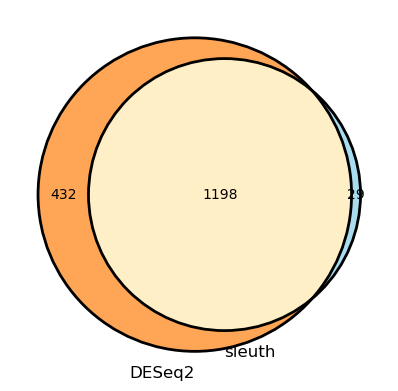

In [6]:
results = matplotlib_venn.venn2(subsets = [x, y], set_labels=['DESeq2', 'sleuth'], set_colors=['tab:orange', 'skyblue'], alpha=0.7)
matplotlib_venn.venn2_circles(subsets=[x, y])  

#matplotlib.pyplot.show()
matplotlib.pyplot.savefig('venn.svg')

In [7]:
common = list(x & y)
print(len(common))
df = pandas.DataFrame(common, columns=['common'])
df.to_csv('my_list.txt', sep='\t', index=False)

1198
